# Importing Libraries

In [296]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer,r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

# Loading Dataset

In [297]:
# Load csv
df=pd.read_csv("Bengaluru_House_Data.csv")

# Basic data inspection

In [298]:
# Basic info
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [299]:
# Shape and Columns
print("Shape :",df.shape)
print("Columns :",df.columns)

Shape : (13320, 9)
Columns : Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='str')


In [300]:
for col in df:
    print(df[col].value_counts())
    print("*"*20)

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
********************
availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64
********************
location
Whitefield                                         540
Sarjapur  Road                                     399
Electronic City                                    302
Kanakpura Road                                     273
Thanisandra                                        234
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      

## Data Cleaning

In [301]:
# Drop these feature (too many misiing values and irelevanr)
df.drop(columns=["society","availability","area_type"],inplace=True)

In [302]:
# Checking null values
df.isnull().sum()

location        1
size           16
total_sqft      0
bath           73
balcony       609
price           0
dtype: int64

In [303]:
# Treating null values

df["size"]=df["size"].fillna("2 BHK")

df["location"]=df["location"].fillna("whitefield")

df["bath"]=df["bath"].fillna(df["bath"].median())

df["balcony"]=df["balcony"].fillna(df["balcony"].median())

In [304]:
# Checking datatypes of columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  str    
 1   size        13320 non-null  str    
 2   total_sqft  13320 non-null  str    
 3   bath        13320 non-null  float64
 4   balcony     13320 non-null  float64
 5   price       13320 non-null  float64
dtypes: float64(3), str(3)
memory usage: 624.5 KB


In [305]:
# Making function for fix datatpe of "total_sqft" str to Float
def ConvertRange(x):
    temp=x.split('-')
    if len(temp)==2:
        return (float(temp[0])+float(temp[1]))/2
    try:
        return float(x)
    except:
        return None

In [306]:
# Fixing datatyp
df["total_sqft"]=df["total_sqft"].apply(ConvertRange)

In [307]:
# making new column
df["bhk"]=df["size"].str.split().str.get(0).astype(float)
df.drop(columns=["size"],inplace=True)

# Exploratory Data Analysis

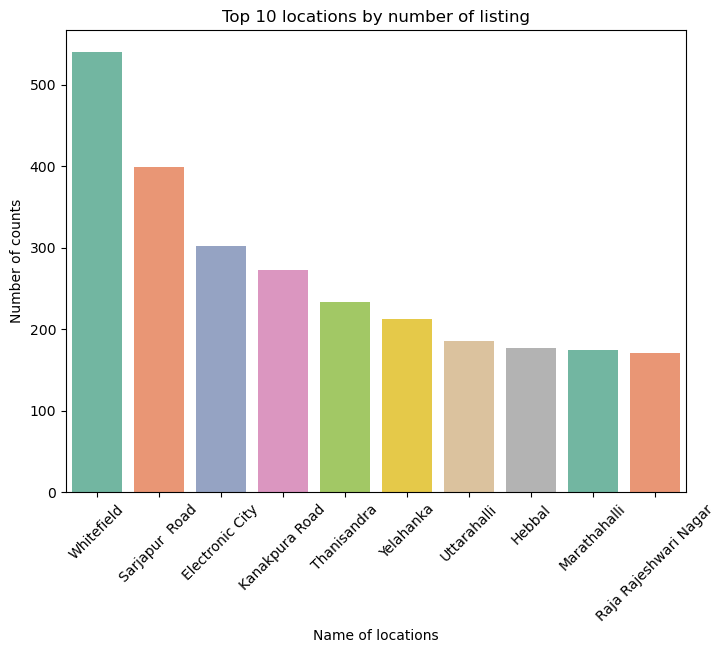

In [308]:
# Top 10 locations

top_locations=df["location"].value_counts().head(10)
plt.figure(figsize=(8,6))
sns.barplot(x=top_locations.index,y=top_locations.values,palette="Set2")
plt.title("Top 10 locations by number of listing")
plt.xticks(rotation=45)
plt.xlabel("Name of locations")
plt.ylabel("Number of counts")
plt.show()

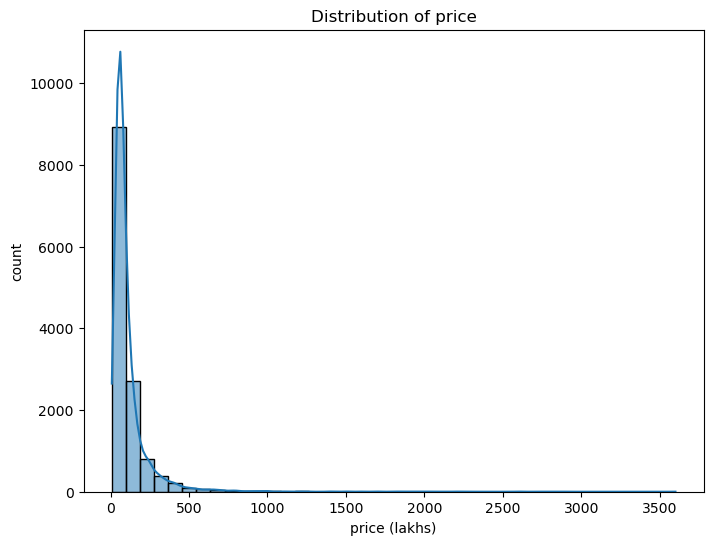

In [309]:
# Distribution of price

plt.figure(figsize=(8,6))
sns.histplot(df["price"],bins=40,kde=True)
plt.title("Distribution of price")
plt.xlabel("price (lakhs)")
plt.ylabel("count")
plt.show()

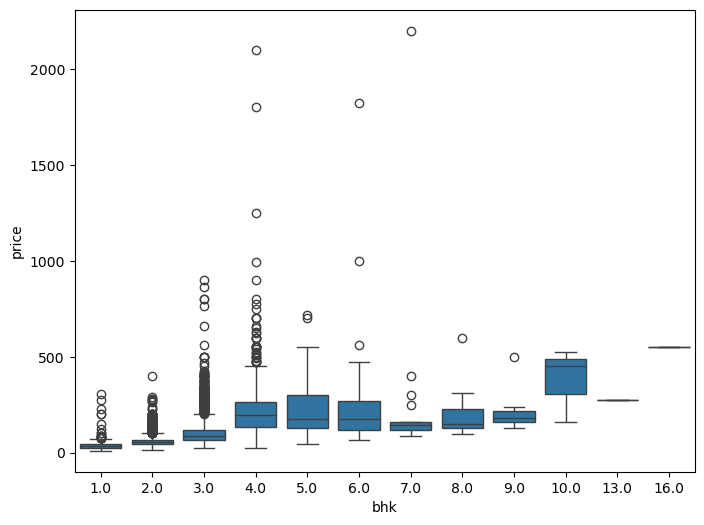

In [332]:
# Boxplot price vs size

plt.figure(figsize=(8,6))
sns.boxplot(x="bhk",y="price",data=df)
plt.xlabel("bhk")
plt.ylabel("price")
plt.show()

# Feature Engineering

In [311]:
# making new column "price_per_sqaure"
df["price_per_square"]=df["price"]*100000/df["total_sqft"]

In [312]:
df.describe()

,total_sqft,bath,balcony,price,bhk,price_per_square
count,13274.000000,13320.000000,13320.000000,13320.000000,13320.000000,1.327400e+04
mean,1559.626694,2.688814,1.603378,112.565627,2.802778,7.907501e+03
std,1238.405258,1.338754,0.803067,148.971674,1.294496,1.064296e+05
min,1.000000,1.000000,0.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,1.000000,50.000000,2.000000,4.266865e+03
50%,1276.000000,2.000000,2.000000,72.000000,3.000000,5.434306e+03
75%,1680.000000,3.000000,2.000000,120.000000,3.000000,7.311746e+03
max,52272.000000,40.000000,3.000000,3600.000000,43.000000,1.200000e+07


In [313]:
df["location"]=df["location"].apply(lambda x: x.strip())
df["location"].value_counts()

location
Whitefield                                         541
Sarjapur  Road                                     399
Electronic City                                    304
Kanakpura Road                                     273
Thanisandra                                        237
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1295, dtype: int64

In [314]:
location_count=df["location"].value_counts()
location_less_10=location_count[location_count<=10]
location_less_10

location
Ganga Nagar                                        10
Dairy Circle                                       10
Sadashiva Nagar                                    10
Naganathapura                                      10
Nagappa Reddy Layout                               10
                                                   ..
Pattegarhpalya                                      1
Tilak Nagar                                         1
12th cross srinivas nagar banshankari 3rd stage     1
Havanur extension                                   1
Abshot Layout                                       1
Name: count, Length: 1054, dtype: int64

In [315]:
df["location"]=df["location"].apply(lambda x: "others" if x in location_less_10 else x)
df["location"].value_counts()

location
others                       2886
Whitefield                    541
Sarjapur  Road                399
Electronic City               304
Kanakpura Road                273
                             ... 
Tindlu                         11
2nd Phase Judicial Layout      11
Marsur                         11
Thyagaraja Nagar               11
HAL 2nd Stage                  11
Name: count, Length: 242, dtype: int64

In [316]:
df.describe()

,total_sqft,bath,balcony,price,bhk,price_per_square
count,13274.000000,13320.000000,13320.000000,13320.000000,13320.000000,1.327400e+04
mean,1559.626694,2.688814,1.603378,112.565627,2.802778,7.907501e+03
std,1238.405258,1.338754,0.803067,148.971674,1.294496,1.064296e+05
min,1.000000,1.000000,0.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,1.000000,50.000000,2.000000,4.266865e+03
50%,1276.000000,2.000000,2.000000,72.000000,3.000000,5.434306e+03
75%,1680.000000,3.000000,2.000000,120.000000,3.000000,7.311746e+03
max,52272.000000,40.000000,3.000000,3600.000000,43.000000,1.200000e+07


In [317]:
(df["total_sqft"]/df["bhk"]).describe()

count    13274.000000
mean       575.074878
std        388.205175
min          0.250000
25%        473.333333
50%        552.500000
75%        625.000000
max      26136.000000
dtype: float64

In [318]:
df=df[((df["total_sqft"]/df["bhk"]>=300))]
df.describe()

,total_sqft,bath,balcony,price,bhk,price_per_square
count,12530.000000,12530.000000,12530.000000,12530.000000,12530.000000,12530.000000
mean,1594.564544,2.559537,1.604629,111.382401,2.650838,6303.979357
std,1261.271296,1.077938,0.796238,152.077329,0.976678,4162.237981
min,300.000000,1.000000,0.000000,8.440000,1.000000,267.829813
25%,1116.000000,2.000000,1.000000,49.000000,2.000000,4210.526316
50%,1300.000000,2.000000,2.000000,70.000000,3.000000,5294.117647
75%,1700.000000,3.000000,2.000000,115.000000,3.000000,6916.666667
max,52272.000000,16.000000,3.000000,3600.000000,16.000000,176470.588235


In [319]:
df.shape

(12530, 7)

In [320]:
def remove_outlier_sqft(df):
    df_output=pd.DataFrame()
    for key,subdf in df.groupby("location"):
        mean=np.mean(subdf.price_per_square)
        std=np.std(subdf.price_per_square)

        gen_df=subdf[(subdf.price_per_square>(mean-std)) & (subdf.price_per_square<=(mean+std))]
        df_output=pd.concat([df_output,gen_df],ignore_index=True)
    return df_output
df=remove_outlier_sqft(df)

In [321]:
df.describe()

,total_sqft,bath,balcony,price,bhk,price_per_square
count,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000
mean,1508.440608,2.471702,1.607514,91.286372,2.574896,5659.062876
std,880.694214,0.979449,0.786178,86.342786,0.897649,2265.774749
min,300.000000,1.000000,0.000000,10.000000,1.000000,1250.000000
25%,1110.000000,2.000000,1.000000,49.000000,2.000000,4244.897959
50%,1286.000000,2.000000,2.000000,67.000000,2.000000,5175.600739
75%,1650.000000,3.000000,2.000000,100.000000,3.000000,6428.571429
max,30400.000000,16.000000,3.000000,2200.000000,16.000000,24509.803922


In [322]:
df.shape

(10301, 7)

In [323]:
def bhk_outlier_remover(df):
    exclude_indices=np.array([])
    for location,location_df in df.groupby("location"):
        bhk_stats={}
        for bhk,bhk_df in df.groupby("bhk"):
            bhk_stats[bhk]={
                "mean":np.mean(bhk_df.price_per_square),
                "std":np.std(bhk_df.price_per_square),
                "count":bhk_df.shape[0]
            }
        for bhk,bhk_df in df.groupby("bhk"):
            stats=bhk_stats.get(bhk-1)
            if stats and stats["count"]<5:
                exclude_indices=np.append(exclude_indices,bhk_df[bhk_df.price_per_square<(stats["mean"])].index.values)
    return df.drop(exclude_indices,axis="index")

In [324]:
df=bhk_outlier_remover(df)

In [327]:
df.drop(columns=["price_per_square"],inplace=True)

# cleaned data

In [329]:
df.head()

,location,total_sqft,bath,balcony,price,bhk
0,1st Block Jayanagar,2850.0,4.0,1.0,428.0,4.0
1,1st Block Jayanagar,1630.0,3.0,2.0,194.0,3.0
2,1st Block Jayanagar,1875.0,2.0,3.0,235.0,3.0
3,1st Block Jayanagar,1200.0,2.0,0.0,130.0,3.0
4,1st Block Jayanagar,1235.0,2.0,2.0,148.0,2.0


In [331]:
df.to_csv("cleaned_data.csv")